In [1]:
#  CELL 1 — INSTALL DEPENDENCIES                          

import subprocess, sys

def pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

pip(
    "transformers", "accelerate", "peft", "bitsandbytes",
    "langchain", "langchain-community", "langchain-core",
    "langchain-text-splitters",
    "langchain-huggingface", "langchain-chroma", "chromadb",
    "sentence-transformers", "safetensors",
    "rank-bm25", "networkx", "spacy",
    "requests", "tqdm", "pandas", "matplotlib", "ipywidgets",
)
subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"], check=True)
print(" All packages installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.7/508.7 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.38.0 requires opentelemetry-exporter-otlp-proto-common==1.38.0, but you have opentelemetry-exporter-otlp-proto-common 1.41.0 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.38.0 requires opentelemetry-proto==1.38.0, but you have opentelemetry-proto 1.41.0 which is incompatible.
open

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 86.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
 All packages installed.


In [2]:
#  CELL 2 — IMPORTS                                        

import os, re, time, pickle, warnings, logging
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime
from typing import Any, Dict, List, Optional
from IPython.display import display, HTML

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import spacy
import networkx as nx
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
print(" Imports OK.")

 Imports OK.


In [3]:
#  CELL 3 — CONFIGURATION                                  

#  Paths 
LORA_PATH   = "/kaggle/input/datasets/mohuamridha/trained-gemma3"  
INDEX_DIR   = "/kaggle/working/ewu_chroma_index"
KG_CACHE    = "/kaggle/working/ewu_kg.pkl"
RESULTS_DIR = "/kaggle/working/results"
for d in [INDEX_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

#  Models 
BASE_MODEL_ID = "google/gemma-3-4b-it"
EMBED_MODEL   = "intfloat/multilingual-e5-base"   
RERANK_MODEL  = "BAAI/bge-reranker-v2-m3"

#  RAG hyper-parameters 
CHUNK_SIZE   = 400
CHUNK_OVERLAP = 60
TOP_K_DENSE  = 8
TOP_K_SPARSE = 6
TOP_K_KG     = 4
TOP_K_FINAL  = 5
RRF_K        = 60

#  EWU Live API 
API_BASE  = "https://ewu-server.onrender.com/api"
API_KEY   = "i6EDytaX4E2jI6GvZQc0b1RSZHTI5_wVRa2rfL7rLpk"
HEADERS   = {"x-api-key": API_KEY}

#  GitHub MD files (Source of data while API fails) 
GITHUB_RAW_BASE = (
    "https://raw.githubusercontent.com/"
    "Cherryberry112/Gemma3-and-RAG-university-admission-Chatbot-/"
    "main/Data%20file%20for%20RAG/"
)

GITHUB_MD_FILES = {
    "dynamic_admission":          "dynamic_Admission.md",
    "dynamic_admission_calendar": "dynamic_admission_calender.md",
    "dynamic_events":             "dynamic_events.md",
    "dynamic_faculty":            "dynamic_faculty.md",
    "dynamic_grading":            "dynamic_gradin.md",
    "static_all_programs":        "static_AllAvailablePrograms.md",
    "static_career_counseling":   "static_Career_Counseling_Center.md",
    "static_departments":         "static_Departments.md",
    "static_policy":              "static_Policy.md",
    "static_programs":            "static_Programs.md",
    "static_rules":               "static_Rules.md",
    "static_sexual_harassment":   "static_Sexual_harassment.md",
    "static_tuition_fees":        "static_Tuition_fees.md",
    "static_about_ewu":           "static_aboutEWU.md",
    "static_admission_process":   "static_admission_procss.md",
    "static_alumni":              "static_alumni.md",
    "static_campus_life":         "static_campus_life.md",
    "static_clubs":               "static_clubs.md",
    "static_facilities":          "static_facilities.md",
    "static_helpdesk":            "static_helpdesk.md",
    "static_payment":             "static_payment_procedure.md",
    "static_scholarship":         "static_scholarship_and_financial.md",
}

#  API endpoints 
API_ENDPOINTS = {
    "programs":           "programs",
    "departments":        "departments",
    "faculty":            "faculty",
    "tuition_fees":       "tuition-fees",
    "scholarships":       "scholarships",
    "clubs":              "clubs",
    "admission_deadlines":"admission-deadlines",
    "grade_scale":        "grade-scale",
    "notices":            "notices",
    "academic_calendar":  "academic-calendar",
    "partnerships":       "partnerships",
}

#  System Prompt 
SYSTEM_PROMPT = """You are EWU Assistant — the official AI assistant of East West University (EWU), Dhaka, Bangladesh.

LANGUAGE RULE (CRITICAL):
- Detect the language of the user's question automatically.
- Reply in EXACTLY the same language the user wrote in.
- Bengali question → Bengali answer. Banglish question → English answer. English question → English answer.
- Never switch languages unless the user explicitly asks.

KNOWLEDGE RULES:
1. Answer ONLY using the provided Context and Structured Facts. Never invent information.
2. If the answer is not in the context, say: "I don't have that specific information. Please contact EWU at info@ewubd.edu or call 09666775577."
3. For fees, CGPA requirements, deadlines — always quote exact numbers from context.
4. Use bullet points for lists. Keep answers focused and accurate.
5. You are EWU Assistant. Never reveal you are Gemma or any AI model.
6. For non-EWU questions: "I can only assist with EWU-related queries."

EWU CONTACT:
- Website: www.ewubd.edu | Email: info@ewubd.edu | admissions@ewubd.edu
- Phone: 09666775577 | Hotline: +8801755587224"""

print(" Config set.")

 Config set.


In [4]:
#  CELL 4 — MD FILE CLEANER                               

def clean_md(raw: str) -> str:
    """
    Clean a raw markdown string for RAG ingestion.
    - Strips heading markers (#) — prevents KG pollution
    - Converts markdown tables to readable prose lines
    - Removes excessive blank lines, horizontal rules
    - Normalises whitespace
    - Keeps ALL content (fees, links, lists) — only formatting removed
    """
    text = raw
    text = re.sub(r"^#{1,6}\s+", "", text, flags=re.MULTILINE)

    def table_to_text(m):
        lines = []
        for row in m.group(0).strip().split("\n"):
            if re.match(r"^\|[\s\-|:]+\|$", row.strip()):
                continue
            cells = [c.strip() for c in row.strip().strip("|").split("|")]
            cells = [c for c in cells if c]
            if cells:
                lines.append(" | ".join(cells))
        return "\n".join(lines)

    text = re.sub(r"(\|.+\|[\s\S]*?(?=\n\n|\Z))", table_to_text, text)
    text = re.sub(r"^[-*_]{3,}\s*$", "", text, flags=re.MULTILINE)
    text = re.sub(r"[*_]{1,2}(.+?)[*_]{1,2}", r"\1", text)
    text = re.sub(r"^[\-\*\+]\s+", "• ", text, flags=re.MULTILINE)
    text = re.sub(r"\n{3,}", "\n\n", text)
    lines = [l.rstrip() for l in text.split("\n")]
    text = "\n".join(lines).strip()
    return text

# Quick sanity check
_test = "## Admission Fee\n| Program | Fee |\n|---------|-----|\n| BBA | 1500 |\n\n**Note**: Pay online."
_cleaned = clean_md(_test)
print("MD cleaner test:")
print(_cleaned)
print("\n MD cleaner ready")

MD cleaner test:
Admission Fee
Program | Fee
BBA | 1500

Note: Pay online.

 MD cleaner ready


In [5]:
#  CELL 5 — DATA LOADING (GitHub MD + Live API)           

def fetch_md_github(filename: str, timeout: int = 20) -> Optional[str]:
    url = GITHUB_RAW_BASE + filename
    try:
        r = requests.get(url, timeout=timeout)
        if r.status_code == 200:
            return r.text
        print(f"   GitHub {filename} → HTTP {r.status_code}")
        return None
    except Exception as e:
        print(f"   GitHub {filename} error: {e}")
        return None


def fetch_api(endpoint: str, timeout: int = 25) -> Any:
    try:
        r = requests.get(f"{API_BASE}/{endpoint}", headers=HEADERS, timeout=timeout)
        if r.status_code == 200:
            data = r.json()
            return data.get("data", data) if isinstance(data, dict) and "data" in data else data
        print(f"   API /{endpoint} → HTTP {r.status_code}")
        return []
    except requests.exceptions.Timeout:
        print(f"   API /{endpoint} timed out")
        return []
    except Exception as e:
        print(f"   API /{endpoint} error: {e}")
        return []


def obj_to_text(obj: Any, _depth: int = 0) -> str:
    if isinstance(obj, str): return obj.strip()
    if isinstance(obj, (int, float, bool)): return str(obj)
    if isinstance(obj, list):
        return "\n".join(obj_to_text(i, _depth) for i in obj if obj_to_text(i, _depth).strip())
    if isinstance(obj, dict):
        parts = []
        for k, v in obj.items():
            label = str(k).replace("_", " ").title()
            val = obj_to_text(v, _depth + 1)
            if val.strip():
                parts.append(f"{label}: {val}")
        return "\n".join(parts)
    return ""


def build_knowledge_base() -> List[Document]:
    docs: List[Document] = []
    loaded_md = 0
    failed_md = []

    print("[1/2] Loading GitHub MD files...")
    for key, filename in tqdm(GITHUB_MD_FILES.items()):
        raw = fetch_md_github(filename)
        if raw and raw.strip():
            cleaned = clean_md(raw)
            if cleaned.strip():
                docs.append(Document(
                    page_content=cleaned[:12000],
                    metadata={"source": f"github_md/{key}", "filename": filename, "type": "md"},
                ))
                loaded_md += 1
        else:
            failed_md.append(filename)
    print(f"   {loaded_md} MD files loaded"
          + (f" |  failed: {failed_md}" if failed_md else ""))

    print("[2/2] Loading Live API endpoints...")
    for label, endpoint in tqdm(API_ENDPOINTS.items()):
        data = fetch_api(endpoint)
        if data:
            text = obj_to_text(data)
            if text.strip():
                docs.append(Document(
                    page_content=text[:10000],
                    metadata={"source": f"api/{label}", "type": "api"}
                ))

    seen, unique = set(), []
    for doc in docs:
        key = doc.page_content[:200]
        if key not in seen:
            seen.add(key)
            unique.append(doc)
    print(f"   Total unique documents: {len(unique)} "
          f"(MD: {sum(1 for d in unique if d.metadata['type']=='md')}, "
          f"API: {sum(1 for d in unique if d.metadata['type']=='api')})")
    return unique


print(" Data loader ready")

 Data loader ready


In [6]:
#  CELL 6 — KNOWLEDGE GRAPH                               
import os
if os.path.exists(KG_CACHE):
    os.remove(KG_CACHE)
    print("Cache cleared — KG will rebuild with new triples")

print("Loading spaCy en_core_web_sm...")
nlp = spacy.load("en_core_web_sm")

ENTITY_ALIASES = {
    "east west university": "EWU",
    "ewu": "EWU",
    "computer science": "CSE",
    "cse": "CSE",
    "business administration": "BBA",
    "bba": "BBA",
    "electrical engineering": "EEE",
    "eee": "EEE",
    "civil engineering": "Civil Engineering",
    "scholarship": "Scholarship",
    "admission": "Admissions",
    "tuition": "Tuition Fees",
    "registrar": "Registrar Office",
    "cgpa": "CGPA",
    "library": "EWU Library",
    "pharmacy": "Pharmacy",
    "law": "Law",
    "economics": "Economics",
    "sociology": "Sociology",
    "mba": "MBA",
    "emba": "EMBA",
    "gpa": "GPA",
    "ssc": "SSC",
    "hsc": "HSC",
}

SEED_TRIPLES = [
    # ── Existing core facts ──────────────────────────────────────
    ("EWU", "full_name", "East West University"),
    ("EWU", "located_in", "Aftabnagar, Dhaka 1212, Bangladesh"),
    ("EWU", "established", "1996"),
    ("EWU", "type", "Private University"),
    ("EWU", "accredited_by", "University Grants Commission Bangladesh"),
    ("EWU", "website", "www.ewubd.edu"),
    ("EWU", "email", "info@ewubd.edu"),
    ("EWU", "admissions_email", "admissions@ewubd.edu"),
    ("EWU", "phone", "09666775577"),
    ("EWU", "hotline", "+8801755587224"),
    ("EWU", "founder", "Dr. Mohammed Farashuddin"),
    ("EWU", "offers", "Undergraduate Programs"),
    ("EWU", "offers", "Graduate Programs"),
    ("EWU", "offers", "Diploma Programs"),

    # ── Admission (covers 4 eval queries) ───────────────────────
    ("Undergraduate Admission", "apply_url", "admission.ewubd.edu"),
    ("Undergraduate Admission", "application_fee", "BDT 1500"),
    ("Undergraduate Admission", "min_gpa_ssc_hsc", "3.00"),
    ("Undergraduate Admission", "diploma_eng_min_gpa", "2.40"),
    ("Undergraduate Admission", "required_documents", "SSC and HSC transcripts, certificates, photos, NID copy"),
    ("Undergraduate Admission", "international_students", "Eligible to apply with equivalent qualifications"),
    ("Undergraduate Admission", "contact", "admissions@ewubd.edu"),

    # ── Programs (covers 3 eval queries) ────────────────────────
    ("CSE", "full_name", "Computer Science and Engineering"),
    ("CSE", "under_faculty", "Faculty of Science and Engineering"),
    ("CSE", "requires", "Math and Physics"),
    ("CSE", "total_credits", "136"),
    ("BBA", "full_name", "Bachelor of Business Administration"),
    ("BBA", "under_faculty", "Faculty of Business and Economics"),
    ("BBA", "total_credits", "126"),
    ("EEE", "full_name", "Electrical and Electronic Engineering"),
    ("EEE", "under_faculty", "Faculty of Science and Engineering"),
    ("Pharmacy", "under_faculty", "Faculty of Science and Engineering"),
    ("Pharmacy", "min_gpa", "8.00 total (3.50 each)"),
    ("Law", "under_faculty", "Faculty of Arts and Social Sciences"),
    ("MBA", "min_cgpa", "2.50"),
    ("MBA", "test_waiver", "EWU CGPA 3.00+ OR other university CGPA 3.50+"),
    ("EMBA", "requires", "Bachelor degree and 2 years executive experience"),
    ("MS CSE", "requires", "Four-year CSE degree"),
    ("LL.M.", "requires", "LL.B. with CGPA 2.50"),

    # ── Fees (covers 2 eval queries) ────────────────────────────
    ("CSE", "tuition_fee_BDT", "205864"),
    ("CSE", "per_credit_fee_BDT", "6600"),
    ("Tuition Fees", "currency", "BDT"),
    ("Tuition Fees", "check_latest", "ewubd.edu/tuition"),

    # ── Scholarships (covers 2 eval queries) ────────────────────
    ("Scholarship", "offered_by", "EWU"),
    ("Merit Scholarship", "requires", "High CGPA"),
    ("Merit Scholarship", "condition", "Must maintain required CGPA each semester"),
    ("Need Based Scholarship", "requires", "Financial need proof"),
    ("Freedom Fighter Scholarship", "offered_by", "EWU"),
    ("Scholarship", "contact", "scholarships@ewubd.edu"),

    # ── Facilities (covers 2 eval queries) ──────────────────────
    ("EWU", "has_facility", "Library"),
    ("EWU", "has_facility", "Medical Centre"),
    ("EWU", "has_facility", "Career Counseling Center"),
    ("EWU", "has_facility", "Cafeteria"),
    ("EWU", "has_facility", "Sports Facilities"),
    ("EWU", "has_facility", "Transport Service"),
    ("Medical Centre", "located_at", "EWU Campus, Aftabnagar"),
    ("EWU", "dormitory", "No on-campus dormitory; affiliated hostels available nearby"),

    # ── Contact (covers 2 eval queries) ─────────────────────────
    ("Registrar Office", "email", "registrar@ewubd.edu"),
    ("Registrar Office", "phone", "09666775577 ext. Registrar"),
    ("CSE Helpdesk", "email", "cse@ewubd.edu"),
    ("Admissions", "contact", "admissions@ewubd.edu"),

    # ── Academic / Credit Transfer (covers 1 eval query) ────────
    ("Credit Transfer", "allowed", "Yes, subject to equivalency and approval"),
    ("Credit Transfer", "contact", "registrar@ewubd.edu"),
    ("CGPA", "scale", "4.0"),

    # ── General / Why EWU (covers 2 eval queries) ───────────────
    ("EWU", "strength", "Strong industry linkage and career support"),
    ("EWU", "strength", "Qualified and experienced faculty"),
    ("EWU", "strength", "Modern campus with full facilities"),
    ("EWU", "strength", "UGC accredited with international partnerships"),
    ("EWU", "notable_alumni", "Available on ewubd.edu/alumni"),

    # ── Events (covers 1 eval query) ────────────────────────────
    ("EWU Events", "check_latest", "ewubd.edu/events"),
    ("EWU Events", "source", "Dynamic API — changes monthly"),

    # ── SSC / HSC requirements ───────────────────────────────────
    ("SSC", "min_gpa_ug", "3.00"),
    ("HSC", "min_gpa_ug", "3.00"),
]

BAD_NODES = re.compile(r"^[#\d\s\W_•]+$")
BAD_RELS  = {"#", "", "g", "h", "j", "k", "a", "b", "--", "related_to", "•"}


def valid_triple(s: str, r: str, o: str) -> bool:
    r = r.strip()
    if r in BAD_RELS or len(r) < 3: return False
    if s.strip().lower() == o.strip().lower(): return False
    if len(s.strip()) < 2 or len(o.strip()) < 2: return False
    if BAD_NODES.match(s.strip()) or BAD_NODES.match(o.strip()): return False
    if s.strip().startswith("#") or o.strip().startswith("#"): return False
    return True


def normalize_ent(text: str) -> str:
    return ENTITY_ALIASES.get(text.lower().strip(), text.strip().title())


DOMAIN_PATTERNS = [
    (r"scholarship[^.]*?(?:require|minimum|maintain)[^.]*?CGPA\s*([\d.]+)",
     "Scholarship", "requires_CGPA", 1),
    (r"(?:minimum|min)[^.]*?GPA[^.]*?([\d.]+)",
     "Admission Requirement", "min_GPA", 1),
    (r"(?:tuition|fee|application fee)[^.]*?(?:is|are|costs?)[^.]*?(?:BDT|Tk\.?|৳)?\s*([\d,]+)",
     "Fees", "amount_BDT", 1),
    (r"([a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+)",
     "Contact", "email", 1),
    (r"(?:phone|call|hotline)[^\d]*([\d\s\-\+]{10,})",
     "EWU", "phone", 1),
    (r"CGPA\s*([\d.]+)\s*(?:or above|and above|minimum|required|exempt)",
     "Requirement", "minimum_CGPA", 1),
    (r"deadline[^.]*?(\d{1,2}\s+\w+\s+\d{4}|\w+\s+\d{1,2},?\s+\d{4})",
     "Admissions", "deadline", 1),
    (r"([A-Z][A-Za-z\s]+)\s+program[^.]*?(?:requires?|needs?)[^.]*?([A-Za-z\s]{5,30})",
     1, "requires", 2),
]


def extract_triples(text: str) -> List[tuple]:
    triples = []
    doc = nlp(text[:30000])
    for sent in doc.sents:
        subj = verb = obj = None
        for token in sent:
            if token.dep_ in ("nsubj", "nsubjpass") and token.pos_ in ("NOUN", "PROPN"):
                subj = token.text
            if token.pos_ == "VERB" and token.dep_ not in ("aux", "auxpass"):
                verb = token.lemma_
            if token.dep_ in ("dobj", "attr", "pobj") and token.pos_ in ("NOUN", "PROPN", "NUM"):
                obj = token.text
        if subj and verb and obj and subj.lower() != obj.lower():
            triples.append((normalize_ent(subj), verb, normalize_ent(obj)))

    for sent in doc.sents:
        ents = [e for e in sent.ents
                if e.label_ in ("ORG", "PERSON", "GPE", "PRODUCT", "MONEY", "CARDINAL", "PERCENT", "DATE")]
        for i in range(len(ents) - 1):
            si, ei = ents[i].end, ents[i + 1].start
            if ei > si:
                rel_tokens = [t.lemma_ for t in doc[si:ei]
                              if t.pos_ in ("VERB", "ADP", "NOUN") and not t.is_stop]
                rel = " ".join(rel_tokens[:3]) if rel_tokens else "associated_with"
            else:
                rel = "associated_with"
            triples.append((normalize_ent(ents[i].text), rel, normalize_ent(ents[i + 1].text)))

    for pattern, subj_or_grp, rel, obj_grp in DOMAIN_PATTERNS:
        for m in re.finditer(pattern, text, re.IGNORECASE):
            try:
                s = m.group(subj_or_grp) if isinstance(subj_or_grp, int) else subj_or_grp
                o = m.group(obj_grp) if isinstance(obj_grp, int) else obj_grp
                if s and o:
                    triples.append((normalize_ent(str(s).strip()), rel, normalize_ent(str(o).strip())))
            except IndexError:
                continue

    seen, unique = set(), []
    for t in triples:
        key = (t[0].lower(), t[1].lower(), t[2].lower())
        if key not in seen and len(t[0]) > 1 and len(t[2]) > 1:
            seen.add(key)
            unique.append(t)
    return unique


def build_kg(docs: List[Document]) -> nx.DiGraph:
    if os.path.exists(KG_CACHE):
        print("  Loading cached KG...")
        with open(KG_CACHE, "rb") as f:
            G = pickle.load(f)
        print(f"   KG: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
        return G

    G = nx.DiGraph()
    for s, r, o in SEED_TRIPLES:
        G.add_edge(s, o, relations=[r], source="curated")

    print(f"  Extracting KG triples from {len(docs)} documents...")
    auto_count = 0
    for doc in tqdm(docs):
        for s, r, o in extract_triples(doc.page_content):
            if not valid_triple(s, r, o):
                continue
            src = doc.metadata.get("source", "")
            if G.has_edge(s, o):
                rels = G[s][o].get("relations", [])
                if r not in rels:
                    rels.append(r)
                G[s][o]["relations"] = rels
            else:
                G.add_edge(s, o, relations=[r], source=src)
                auto_count += 1

    with open(KG_CACHE, "wb") as f:
        pickle.dump(G, f)
    print(f"   KG: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges "
          f"({auto_count} auto + {len(SEED_TRIPLES)} curated)")
    return G


def kg_retrieve(query: str, G: nx.DiGraph) -> List[Document]:
    ql = query.lower()
    STOP = {
        "what", "does", "offer", "have", "about", "tell", "available", "used",
        "there", "their", "that", "this", "with", "from", "will", "university",
        "east", "west", "ewu", "how", "when", "where", "who", "which", "please",
        "can", "the", "for", "and", "are", "is", "in", "of", "at",
        "কি", "কী", "কোন", "আছে", "আমি", "আপনি", "কত", "কোথায়", "কখন", "কিভাবে",
    }
    keywords = [w for w in re.findall(r"\b\w{3,}\b", ql) if w not in STOP]
    scored = []
    for node in G.nodes():
        if BAD_NODES.match(str(node).strip()):
            continue
        nl = node.lower()
        if nl in ql or ql in nl:
            scored.append((node, 3))
        elif any(kw in nl or nl in kw for kw in keywords):
            scored.append((node, 2))
        elif any(kw in nl for kw in keywords if len(kw) > 4):
            scored.append((node, 1))

    seen_set, ordered = set(), []
    for node, _ in sorted(scored, key=lambda x: x[1], reverse=True):
        if node not in seen_set:
            seen_set.add(node)
            ordered.append(node)
    if not ordered:
        ordered = [n for n in ["EWU"] if n in G.nodes()]
    elif "EWU" in ordered and len(ordered) > 1:
        ordered = [n for n in ordered if n != "EWU"]

    facts, seen_facts = [], set()
    for node in ordered[:6]:
        for _, nb, data in G.out_edges(node, data=True):
            for rel in data.get("relations", []):
                if valid_triple(node, rel, nb):
                    s = f"{node} --[{rel}]--> {nb}"
                    if s not in seen_facts:
                        seen_facts.add(s)
                        facts.append(Document(
                            page_content=s,
                            metadata={"type": "kg_triple", "source": data.get("source", "KG")}
                        ))
        for nb, _, data in G.in_edges(node, data=True):
            for rel in data.get("relations", []):
                if valid_triple(nb, rel, node):
                    s = f"{nb} --[{rel}]--> {node}"
                    if s not in seen_facts:
                        seen_facts.add(s)
                        facts.append(Document(
                            page_content=s,
                            metadata={"type": "kg_triple", "source": data.get("source", "KG")}
                        ))
    return facts[:TOP_K_KG]


print(" Knowledge Graph module ready")

Loading spaCy en_core_web_sm...
 Knowledge Graph module ready


In [7]:
#  CELL 7 — SEMANTIC VECTOR INDEX + BM25                  

def build_vector_index(docs: List[Document]):
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"  Embedding device: {DEVICE}")

    class E5Multilingual(HuggingFaceEmbeddings):
        def embed_documents(self, texts: List[str]) -> List[List[float]]:
            return super().embed_documents([f"passage: {t}" for t in texts])
        def embed_query(self, text: str) -> List[float]:
            return super().embed_query(f"query: {text}")

    emb = E5Multilingual(
        model_name=EMBED_MODEL,
        model_kwargs={"device": DEVICE},
        encode_kwargs={"normalize_embeddings": True, "batch_size": 64},
    )

    vs = Chroma(
        collection_name="ewu_md_e5_rag",
        embedding_function=emb,
        persist_directory=INDEX_DIR,
    )

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
        separators=["\n\n", "\n", ". ", "। ", "• ", ", ", " "],
    )

    all_chunks: List[Document] = []
    if vs._collection.count() == 0:
        print(f"  Building index from {len(docs)} documents...")
        for doc in tqdm(docs):
            chunks = splitter.split_text(doc.page_content)
            for chunk_text in chunks:
                chunk_text = chunk_text.strip()
                if len(chunk_text) > 30:
                    all_chunks.append(Document(page_content=chunk_text, metadata=doc.metadata))
        if all_chunks:
            BATCH = 200
            for i in range(0, len(all_chunks), BATCH):
                vs.add_documents(all_chunks[i: i + BATCH])
            print(f"  ✓ Vector index: {len(all_chunks)} chunks")
        else:
            print("  ⚠ No chunks built — check documents!")
    else:
        print(f"  Loading existing index: {vs._collection.count()} chunks")
        raw = vs._collection.get(include=["documents", "metadatas"])
        for text, meta in zip(raw["documents"], raw["metadatas"]):
            all_chunks.append(Document(page_content=text, metadata=meta))

    return vs, emb, all_chunks


def build_bm25(chunks: List[Document]) -> BM25Okapi:
    tokenized = [doc.page_content.lower().split() for doc in chunks]
    return BM25Okapi(tokenized)


print(" Vector index module ready")

 Vector index module ready


In [8]:
#  CELL 8 — HYBRID RETRIEVAL (Dense + BM25 + KG + RRF)    

def rrf_fuse(*ranked_lists, k: int = RRF_K) -> List[Document]:
    scores: Dict[str, float] = {}
    doc_map: Dict[str, Document] = {}
    for ranked in ranked_lists:
        for rank, doc in enumerate(ranked):
            key = doc.page_content[:120]
            scores[key] = scores.get(key, 0.0) + 1.0 / (k + rank + 1)
            doc_map[key] = doc
    return [doc_map[k] for k in sorted(scores, key=lambda x: scores[x], reverse=True)]


def rerank_docs(query: str, docs: List[Document], reranker: CrossEncoder) -> List[Document]:
    if not docs:
        return docs
    chunk_docs = [d for d in docs if d.metadata.get("type") != "kg_triple"]
    kg_docs    = [d for d in docs if d.metadata.get("type") == "kg_triple"]

    if chunk_docs:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            scores = reranker.predict([(query, d.page_content) for d in chunk_docs])
        ranked = [d for _, d in sorted(zip(scores, chunk_docs), reverse=True)]
        ranked = ranked[:TOP_K_FINAL]
    else:
        ranked = []
    return ranked + kg_docs[:3]


def hybrid_retrieve(
    query: str,
    vs: Chroma,
    bm25: BM25Okapi,
    all_chunks: List[Document],
    KG: nx.DiGraph,
    reranker: CrossEncoder,
) -> Dict:
    dense_docs  = vs.similarity_search(query, k=TOP_K_DENSE)
    tokens      = query.lower().split()
    bm25_scores = bm25.get_scores(tokens)
    top_idx     = np.argsort(bm25_scores)[::-1][:TOP_K_SPARSE]
    sparse_docs = [all_chunks[i] for i in top_idx if bm25_scores[i] > 0]
    kg_docs     = kg_retrieve(query, KG)
    fused       = rrf_fuse(dense_docs, sparse_docs)
    reranked    = rerank_docs(query, fused + kg_docs, reranker)

    chunks   = [d for d in reranked if d.metadata.get("type") != "kg_triple"]
    kg_facts = [d for d in reranked if d.metadata.get("type") == "kg_triple"]
    in_reranked = {d.page_content for d in kg_facts}
    for d in kg_docs:
        if d.page_content not in in_reranked:
            kg_facts.append(d)

    return {"chunks": chunks, "kg_facts": kg_facts[:4], "all_docs": reranked}


print(" Hybrid retrieval ready")

 Hybrid retrieval ready


In [9]:
#  CELL 9 — LOAD FINE-TUNED GEMMA-3 + LORA               

def load_model(lora_path: str):
    from kaggle_secrets import UserSecretsClient
    from huggingface_hub import login

    hf_token = UserSecretsClient().get_secret("HF_TOKEN")
    login(token=hf_token)
    print("   HuggingFace login")

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"  Device: {DEVICE}")

    assert os.path.isdir(lora_path), f"LoRA path not found: {lora_path}"
    files = os.listdir(lora_path)
    assert "adapter_config.json" in files, "adapter_config.json missing"
    assert "adapter_model.safetensors" in files, "adapter_model.safetensors missing"
    print(f"   LoRA files found at {lora_path}")

    tok_src = lora_path if "tokenizer.json" in files else BASE_MODEL_ID
    tok = AutoTokenizer.from_pretrained(tok_src, use_fast=True)
    print(f"   Tokenizer loaded from: {tok_src}")
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    tok.padding_side = "right"

    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )

    print("  Loading base Gemma-3-4B-IT (4-bit)...")
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        quantization_config=bnb_cfg,
        device_map="auto",
        trust_remote_code=True,
    )
    base.config.use_cache = False
    base.config.pad_token_id = tok.pad_token_id

    print(f"  Attaching LoRA from {lora_path}...")
    model = PeftModel.from_pretrained(base, lora_path)
    model.eval()
    print(f"  ✓ Fine-tuned Gemma-3 ready on {model.device}")

    test_prompt = (
        f"<start_of_turn>system\n{SYSTEM_PROMPT}<end_of_turn>\n"
        f"<start_of_turn>user\nWhat is EWU?<end_of_turn>\n"
        f"<start_of_turn>model\n"
    )
    with torch.no_grad():
        _raw = tok(test_prompt, return_tensors="pt")
        inp  = {k: v.to(model.device) for k, v in _raw.items()}
        if "token_type_ids" not in inp:
            inp["token_type_ids"] = torch.zeros_like(inp["input_ids"])
        out = model.generate(**inp, max_new_tokens=60, do_sample=False,
                             pad_token_id=tok.pad_token_id)
    ans = tok.decode(out[0][inp["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    print(f"  Smoke test → {ans[:120]}")
    return tok, model


print(" Model loader ready")

 Model loader ready


In [10]:
#  CELL 10 — CHAT LOGIC                                   

SMALL_TALK = {
    r"\b(who\s+are\s+you|what\s+are\s+you|তুমি\s+কে|আপনি\s+কে)\b":
        "I'm EWU Assistant — the official virtual assistant of East West University, Dhaka. How can I help? ",
    r"\b(what\s+can\s+you\s+do|how\s+can\s+you\s+help)\b":
        "I can help with EWU admissions, programs, tuition fees, scholarships, grading, departments, clubs, facilities, faculty, and more!",
    r"^\s*(hi|hello|hey|salam|assalamu|হ্যালো|নমস্কার|হেই)\b":
        "Hello! Welcome to EWU Assistant. How can I help you today? ",
    r"\bthank":
        "You're welcome! Feel free to ask anything about EWU. ",
    r"\b(bye|goodbye|বিদায়|আল্লাহ\s*হাফেজ)\b":
        "Goodbye! Visit www.ewubd.edu for more info. Take care!",
}


def build_prompt(chunks: List[Document], kg_facts: List[Document], question: str) -> str:
    context_parts = [d.page_content.strip() for d in chunks]
    context = "\n\n---\n\n".join(context_parts)
    if len(context) > 3500:
        context = context[:3500]

    kg_lines = [
        f"• {d.page_content}"
        for d in kg_facts
        if "--[" in d.page_content and "-->" in d.page_content
        and len(d.page_content) > 10
        and not d.page_content.startswith("#")
        and not d.page_content.startswith("•")
    ]
    kg_section = ""
    if kg_lines:
        kg_section = "\n\nStructured Facts (Knowledge Graph):\n" + "\n".join(kg_lines[:4])

    user_content = (
        f"Context:\n{context}"
        f"{kg_section}\n\n"
        f"Question: {question}"
    )
    return (
        f"<start_of_turn>system\n{SYSTEM_PROMPT}<end_of_turn>\n"
        f"<start_of_turn>user\n{user_content}<end_of_turn>\n"
        f"<start_of_turn>model\n"
    )


def generate(prompt: str, tok, model, max_new_tokens: int = 400) -> str:
    raw_enc = tok(prompt, return_tensors="pt", truncation=True, max_length=3200)
    enc = {k: v.to(model.device) for k, v in raw_enc.items()}
    if "token_type_ids" not in enc:
        enc["token_type_ids"] = torch.zeros_like(enc["input_ids"])

    eot_id = tok.convert_tokens_to_ids("<end_of_turn>")
    if not eot_id or eot_id == tok.unk_token_id:
        eot_id = tok.eos_token_id

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.3,
            eos_token_id=eot_id,
            pad_token_id=tok.pad_token_id,
        )

    new_tokens = out[0][enc["input_ids"].shape[1]:]
    answer = tok.decode(new_tokens, skip_special_tokens=True).strip()

    for stop in ["<end_of_turn>", "<start_of_turn>", "Instruct:", "Question:", "\nContext:"]:
        answer = answer.split(stop)[0].strip()

    if answer:
        sentences = re.split(r"(?<=[.!?।])\s+", answer)
        if len(sentences) > 1 and not re.search(r"[.!?।]$", sentences[-1].strip()):
            answer = " ".join(sentences[:-1])

    return answer.strip()


def chat(
    user_query: str,
    tok, model,
    vs: Chroma,
    bm25: BM25Okapi,
    all_chunks: List[Document],
    KG: nx.DiGraph,
    reranker: CrossEncoder,
) -> Dict:
    t_start = time.time()
    result = {"query": user_query, "answer": "", "kg_facts": [], "sources": [], "time_s": 0.0}

    q = (user_query or "").strip()
    if not q:
        result["answer"] = "Please ask a question about East West University."
        result["time_s"] = round(time.time() - t_start, 2)
        return result

    for pattern, reply in SMALL_TALK.items():
        if re.search(pattern, q, re.IGNORECASE):
            result["answer"] = reply
            result["time_s"] = round(time.time() - t_start, 2)
            return result

    ret    = hybrid_retrieve(q, vs, bm25, all_chunks, KG, reranker)
    chunks = ret["chunks"]
    kgf    = ret["kg_facts"]

    if not chunks and not kgf:
        result["answer"] = (
            "I couldn't find relevant information for your query.\n"
            "Please contact EWU: info@ewubd.edu | 09666775577 | www.ewubd.edu"
        )
        result["time_s"] = round(time.time() - t_start, 2)
        return result

    result["kg_facts"] = [d.page_content for d in kgf]
    result["sources"]  = list({d.metadata.get("source", "") for d in chunks})

    prompt = build_prompt(chunks, kgf, q)
    answer = generate(prompt, tok, model)
    if not answer or len(answer.strip()) < 20:
        answer = (chunks[0].page_content[:500].strip() if chunks
                  else "I couldn't generate a response. Please contact info@ewubd.edu.")

    result["answer"] = answer
    result["time_s"] = round(time.time() - t_start, 2)
    return result


print(" Chat logic ready")

 Chat logic ready


In [11]:
#  CELL 11 — INITIALISE ALL SYSTEMS                       

print("=" * 60)
print("  EWU CHATBOT — INITIALISATION")
print("=" * 60)

print("\n[1/5] Building knowledge base (GitHub MD + API)...")
KB_DOCS = build_knowledge_base()

print("\n[2/5] Building Knowledge Graph...")
KG = build_kg(KB_DOCS)

print("\n[3/5] Building semantic vector index + BM25...")
VS, EMB, ALL_CHUNKS = build_vector_index(KB_DOCS)
BM25_INDEX = build_bm25(ALL_CHUNKS)
print(f"   BM25 over {len(ALL_CHUNKS)} chunks")

print("\n[4/5] Loading BGE reranker...")
_DEV = "cuda" if torch.cuda.is_available() else "cpu"
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    RERANKER = CrossEncoder(RERANK_MODEL, device=_DEV, max_length=512)
print("   BGE reranker loaded")

print("\n[5/5] Loading fine-tuned Gemma-3 + LoRA...")
TOK, MODEL = load_model(LORA_PATH)


print("   ALL SYSTEMS READY")


  EWU CHATBOT — INITIALISATION

[1/5] Building knowledge base (GitHub MD + API)...
[1/2] Loading GitHub MD files...


100%|██████████| 22/22 [00:03<00:00,  6.51it/s]


   22 MD files loaded
[2/2] Loading Live API endpoints...


  9%|▉         | 1/11 [00:25<04:11, 25.13s/it]

   API /programs timed out


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

  Attaching LoRA from /kaggle/input/datasets/mohuamridha/trained-gemma3...
  ✓ Fine-tuned Gemma-3 ready on cuda:0
  Smoke test → EWU stands for East West University.
   ALL SYSTEMS READY


In [12]:
#  CELL 12 — EVALUATION QUESTIONS      


EVAL_QUESTIONS = [
    #  English 
    {"q": "What is the current application deadline for undergraduate programs?",           "cat": "Admission"},
    {"q": "How can I apply for admission?",                                                 "cat": "Admission"},
    {"q": "What documents are needed for the admission process?",                          "cat": "Admission"},
    {"q": "How many courses are there in the CSE department?",                             "cat": "Programs"},
    {"q": "Can you show me the list of departments offered by the university?",            "cat": "Programs"},
    {"q": "Tell me about the BBA total credits.",                                          "cat": "Programs"},
    {"q": "Why should I get admitted into EWU?",                                           "cat": "General"},
    {"q": "What is the current tuition fee for Computer Science?",                         "cat": "Fees"},
    {"q": "Are there any scholarship opportunities?",                                       "cat": "Scholarship"},
    {"q": "What are the terms and conditions for merit scholarships?",                     "cat": "Scholarship"},
    {"q": "Has there been a recent change in the per credit fee for CSE courses?",         "cat": "Fees"},
    {"q": "Where is East West University located?",                                        "cat": "General"},
    {"q": "Can you tell me about some notable EWU alumni?",                                "cat": "General"},
    {"q": "Is there any medical center in the university?",                                "cat": "Facilities"},
    {"q": "How can I contact the registrar's office?",                                     "cat": "Contact"},
    {"q": "Give me the email of the CSE department helpdesk.",                             "cat": "Contact"},
    {"q": "Are there any events happening this month?",                                    "cat": "Events"},
    {"q": "Can international students apply for admission?",                               "cat": "Admission"},
    {"q": "Does the university offer on-campus or affiliated dormitory/hostel accommodation?", "cat": "Facilities"},
    {"q": "Can I transfer my credits?",                                                    "cat": "Academic"},

    #  Bengali (বাংলা) 
    {"q": "স্নাতক প্রোগ্রামগুলোর জন্য আবেদনের বর্তমান শেষ তারিখ কবে?",                 "cat": "Admission"},
    {"q": "আমি কীভাবে ভর্তির জন্য আবেদন করতে পারি?",                                    "cat": "Admission"},
    {"q": "ভর্তি প্রক্রিয়ার জন্য কী কী কাগজপত্র প্রয়োজন?",                            "cat": "Admission"},
    {"q": "সিএসই বিভাগে কয়টি কোর্স আছে?",                                              "cat": "Programs"},
    {"q": "বিশ্ববিদ্যালয়ে যে বিভাগগুলো রয়েছে সেগুলোর তালিকা দেখাতে পারবে?",          "cat": "Programs"},
    {"q": "বিবিএ কোর্সের মোট ক্রেডিট সম্পর্কে বলো।",                                   "cat": "Programs"},
    {"q": "আমি কেন ইস্ট ওয়েস্ট ইউনিভার্সিটিতে ভর্তি হব?",                             "cat": "General"},
    {"q": "কম্পিউটার সায়েন্সের বর্তমান টিউশন ফি কত?",                                  "cat": "Fees"},
    {"q": "কোনো স্কলারশিপের সুযোগ আছে কি?",                                             "cat": "Scholarship"},
    {"q": "মেরিট স্কলারশিপের শর্তাবলি কী?",                                              "cat": "Scholarship"},
    {"q": "সিএসই কোর্সগুলোর প্রতি ক্রেডিট ফিতে কি সম্প্রতি কোনো পরিবর্তন হয়েছে?",   "cat": "Fees"},
    {"q": "ইস্ট ওয়েস্ট ইউনিভার্সিটি কোথায় অবস্থিত?",                                 "cat": "General"},
    {"q": "EWU-এর কিছু উল্লেখযোগ্য প্রাক্তন শিক্ষার্থীর সম্পর্কে বলতে পারবে?",       "cat": "General"},
    {"q": "বিশ্ববিদ্যালয়ে কি কোনো চিকিৎসা কেন্দ্র আছে?",                              "cat": "Facilities"},
    {"q": "আমি কীভাবে রেজিস্ট্রারের অফিসের সাথে যোগাযোগ করতে পারি?",                  "cat": "Contact"},
    {"q": "আমাকে সিএসই বিভাগের হেল্পডেস্কের ইমেইলটি দিন।",                             "cat": "Contact"},
    {"q": "এই মাসে কি কোনো অনুষ্ঠান হচ্ছে?",                                            "cat": "Events"},
    {"q": "আন্তর্জাতিক শিক্ষার্থীরা কি ভর্তির জন্য আবেদন করতে পারে?",                 "cat": "Admission"},
    {"q": "বিশ্ববিদ্যালয় কি ক্যাম্পাসের ভেতরে বা অনুমোদিত ছাত্রাবাস/হোস্টেলে থাকার ব্যবস্থা করে?", "cat": "Facilities"},
    {"q": "আমি কি আমার ক্রেডিটগুলো স্থানান্তর করতে পারি?",                             "cat": "Academic"},

    #  Banglish
    {"q": "Undergraduate programgular bortoman vorti abedoner shesh shomoyshima ki?",      "cat": "Admission"},
    {"q": "Ami kibhabe vorti-r jonno abedon korte pari?",                                  "cat": "Admission"},
    {"q": "Vorti prokriyar jonno ki ki document proyojon?",                                "cat": "Admission"},
    {"q": "CSE bibhage koyti course ache?",                                                "cat": "Programs"},
    {"q": "Bishwabidyaloye je bibhaggulo royeche segulor talika dekhate parbe?",           "cat": "Programs"},
    {"q": "BBA er mot credit somporke bolo.",                                              "cat": "Programs"},
    {"q": "Ami keno East West University-te vorti hobo?",                                  "cat": "General"},
    {"q": "Computer Science-er bortoman tuition fee koto?",                                "cat": "Fees"},
    {"q": "Kono scholarship-er sujog ache ki?",                                            "cat": "Scholarship"},
    {"q": "Merit scholarship-er shortaboli ki?",                                           "cat": "Scholarship"},
    {"q": "CSE coursegular proti credit fee-te ki shomproti kono poriborton hoyeche?",    "cat": "Fees"},
    {"q": "East West University kothay obosthito?",                                        "cat": "General"},
    {"q": "EWU-er kichu ullokkhoggo praktan shikkharthir somporke bolte parbe?",          "cat": "General"},
    {"q": "Bishwabidyaloye ki kono medical center ache?",                                  "cat": "Facilities"},
    {"q": "Ami kibhabe registrar office-er sathe jogajog korte pari?",                    "cat": "Contact"},
    {"q": "CSE department-er helpdesk-er email dao.",                                      "cat": "Contact"},
    {"q": "Ei mashe ki kono event hocche?",                                                "cat": "Events"},
    {"q": "International shikkharthira ki vorti-r jonno abedon korte pare?",              "cat": "Admission"},
    {"q": "Bishwabidyaloy ki on-campus ba shongjukto dormitory/hostel subidha dey?",      "cat": "Facilities"},
    {"q": "Ami ki amar credit transfer korte pari?",                                       "cat": "Academic"},
]


In [13]:
#  CELL 13 — RUN EVALUATION                              

def run_evaluation(questions: List[Dict], show_kg: bool = False) -> pd.DataFrame:
    """Run all evaluation questions and return a results DataFrame."""
    results = []
    total   = len(questions)
    print(f"Running {total} evaluation questions...\n{'='*65}")

    for i, item in enumerate(questions, 1):
        res = chat(item["q"], TOK, MODEL, VS, BM25_INDEX, ALL_CHUNKS, KG, RERANKER)

        lang = "Bengali" if any(c > '\u0900' for c in item["q"]) \
               else ("Banglish" if re.search(r'\b(te|er|jonno|koto|kemon|ache|lagbe|nite)\b',
                                             item["q"], re.I) else "English")

        print(f"\n[{i:02d}/{total}] [{item['cat']}] [{lang}]")
        print(f"  Q: {item['q']}")
        print(f"  A: {res['answer'][:300]}{'...' if len(res['answer'])>300 else ''}")
        print(f"  ⏱ Response time: {res['time_s']:.2f}s")
        if show_kg and res["kg_facts"]:
            print(f"  KG: {res['kg_facts'][0][:80]}")

        results.append({
            "#":       i,
            "language":lang,
            "category":item["cat"],
            "question":item["q"],
            "answer":  res["answer"],
            "kg_used": " | ".join(res["kg_facts"][:2]),
            "sources": " | ".join(res["sources"][:2]),
            "time_s":  res["time_s"],
        })

    df = pd.DataFrame(results)
    ts  = datetime.now().strftime("%Y%m%d_%H%M")
    csv_path = f"{RESULTS_DIR}/eval_{ts}.csv"
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")

    # Summary stats
    print(f"\n{'='*65}")
    print(f"Evaluation complete → {csv_path}")
    print(f"Total questions : {len(df)}")
    print(f"Avg time        : {df['time_s'].mean():.2f}s")
    print(f"Min / Max time  : {df['time_s'].min():.2f}s / {df['time_s'].max():.2f}s")
    print(f"KG coverage     : {(df['kg_used'].str.len() > 2).mean()*100:.0f}% of queries used KG")
    print("\nAvg time by language:")
    print(df.groupby("language")["time_s"].mean().round(2).to_string())
    print("\nAvg time by category:")
    print(df.groupby("category")["time_s"].mean().sort_values().round(2).to_string())
    return df


# Run evaluation
EVAL_DF = run_evaluation(EVAL_QUESTIONS, show_kg=True)

Running 60 evaluation questions...

[01/60] [Admission] [English]
  Q: What is the current application deadline for undergraduate programs?
  A: The last date to apply for undergraudate program varies by year but it will appear here once available..
  ⏱ Response time: 7.46s
  KG: EWU --[offers]--> Undergraduate Programs

[02/60] [Admission] [English]
  Q: How can I apply for admission?
  A: To start applying visit this link:[https://admission.ewubd.edu/]
  ⏱ Response time: 6.70s
  KG: Mis --[associated_with]--> Department Of Economics
Undergraduate Programs
• Bach

[03/60] [Admission] [English]
  Q: What documents are needed for the admission process?
  A: Documents include a passport sized color picture(240 W x 300 H pixels), scanned signature(300 W x 80 H pixels), transcript copies, certificates like SSC & HSC marksheets.
  ⏱ Response time: 11.60s
  KG: Document --[outline]--> University

[04/60] [Programs] [English]
  Q: How many courses are there in the CSE department?
  A: The num

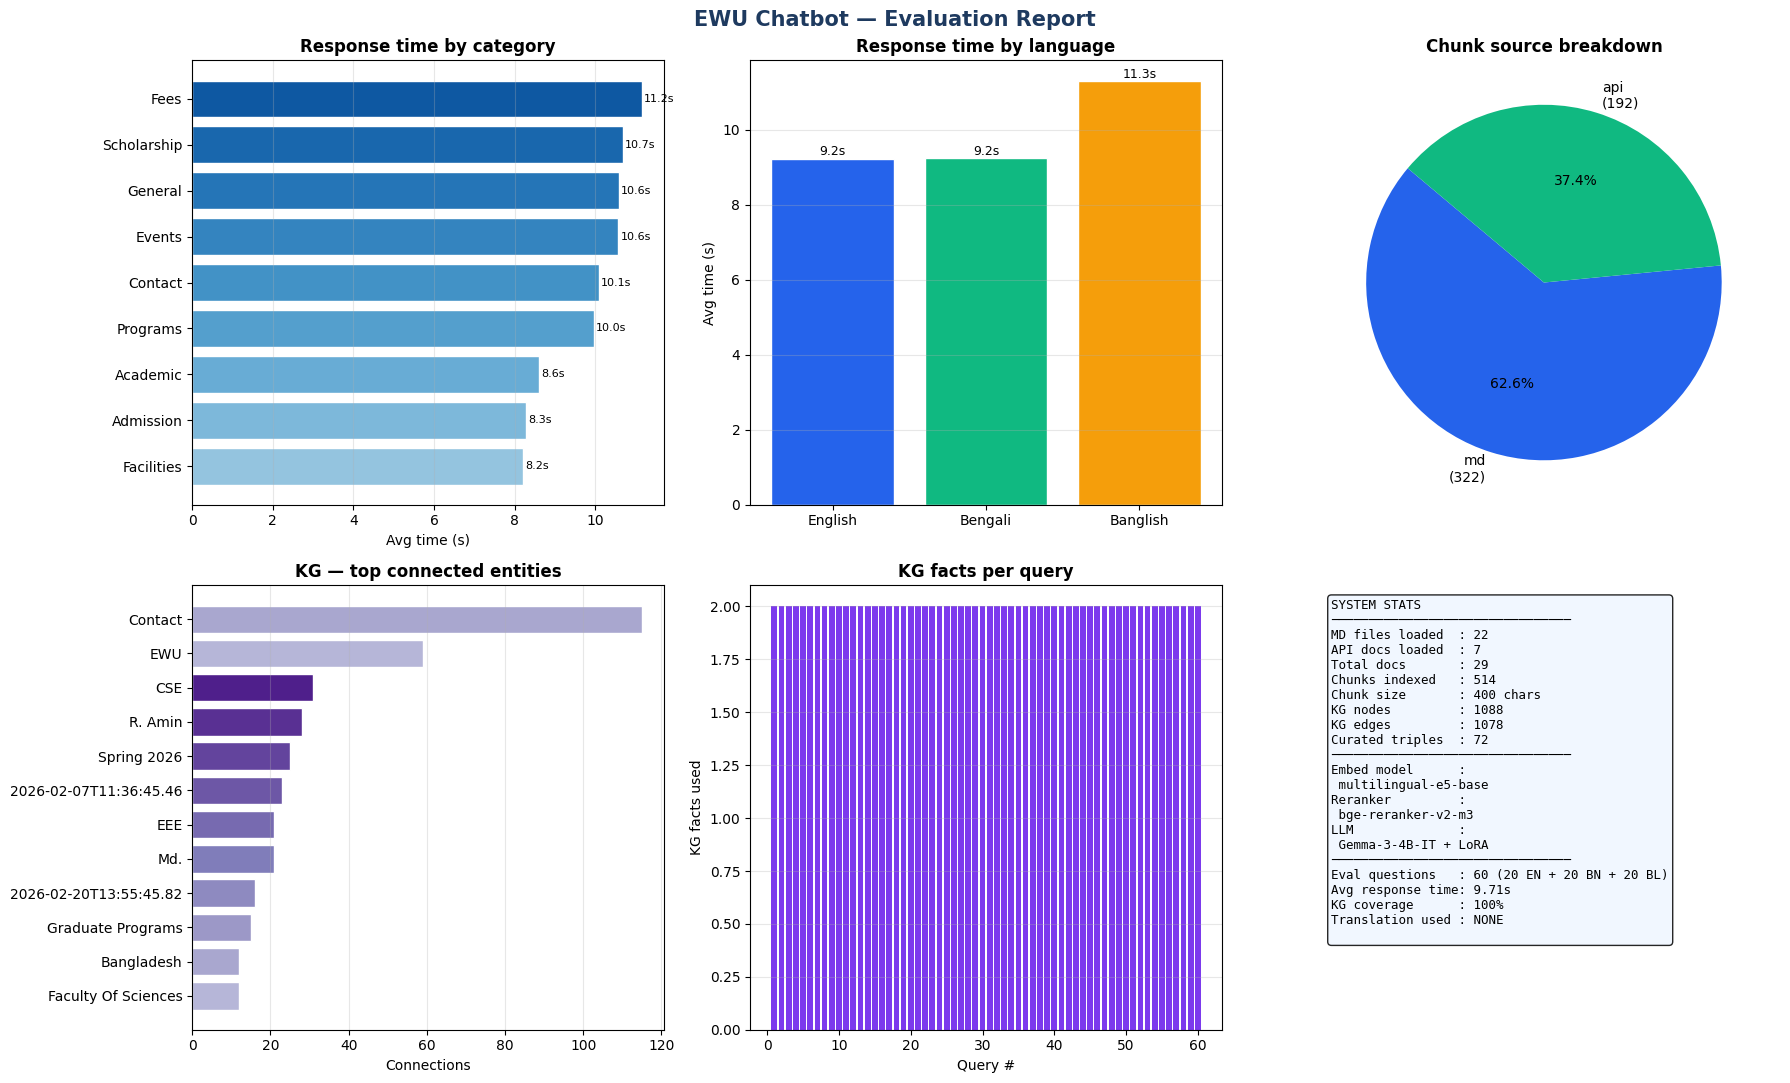

Chart saved → /kaggle/working/results/eval_report_20260409_1854.png


In [14]:
#  CELL 14 — EVALUATION CHARTS                            

def plot_eval(df: pd.DataFrame, all_chunks: List[Document], KG: nx.DiGraph):
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle("EWU Chatbot — Evaluation Report",
                 fontsize=15, fontweight="bold", color="#1e3a5f")

    colors_blue   = plt.cm.Blues(np.linspace(0.4, 0.9, 10))
    colors_purple = plt.cm.Purples(np.linspace(0.4, 0.9, 10))

    # 1) Response time by category
    ax = axes[0, 0]
    cat_t = df.groupby("category")["time_s"].mean().sort_values()
    bars  = ax.barh(cat_t.index, cat_t.values,
                    color=colors_blue[:len(cat_t)], edgecolor="white")
    ax.set_xlabel("Avg time (s)")
    ax.set_title("Response time by category", fontweight="bold")
    for bar, val in zip(bars, cat_t.values):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}s", va="center", fontsize=8)
    ax.grid(axis="x", alpha=0.3)

    # 2) Response time by language
    ax = axes[0, 1]
    lang_t      = df.groupby("language")["time_s"].mean().sort_values()
    lang_colors = ["#2563EB", "#10B981", "#F59E0B"]
    bars2       = ax.bar(lang_t.index, lang_t.values,
                         color=lang_colors[:len(lang_t)], edgecolor="white")
    ax.set_ylabel("Avg time (s)")
    ax.set_title("Response time by language", fontweight="bold")
    for bar, val in zip(bars2, lang_t.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f"{val:.1f}s", ha="center", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    # 3) Chunk source type breakdown
    ax = axes[0, 2]
    src_types = Counter([c.metadata.get("type", "unknown") for c in all_chunks])
    ax.pie(src_types.values(),
           labels=[f"{k}\n({v})" for k, v in src_types.items()],
           autopct="%1.1f%%", startangle=140,
           colors=["#2563EB", "#10B981", "#F59E0B", "#8B5CF6"])
    ax.set_title("Chunk source breakdown", fontweight="bold")

    # 4) KG top entities by degree
    ax = axes[1, 0]
    clean_nodes = [(n, d) for n, d in KG.degree
                   if not BAD_NODES.match(str(n).strip()) and not str(n).startswith("#")]
    top_ents = sorted(clean_nodes, key=lambda x: x[1], reverse=True)[:12]
    names    = [e[0][:22] for e in top_ents]
    degs     = [e[1] for e in top_ents]
    ax.barh(names[::-1], degs[::-1],
            color=colors_purple[:len(names)], edgecolor="white")
    ax.set_xlabel("Connections")
    ax.set_title("KG — top connected entities", fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

    # 5) KG facts used per query
    ax = axes[1, 1]
    df["kg_count"] = df["kg_used"].apply(
        lambda x: len(str(x).split("|")) if str(x).strip() and str(x) != "nan" else 0
    )
    bar_colors = ["#7C3AED" if c > 0 else "#D1D5DB" for c in df["kg_count"]]
    ax.bar(df["#"], df["kg_count"], color=bar_colors)
    ax.set_xlabel("Query #")
    ax.set_ylabel("KG facts used")
    ax.set_title("KG facts per query", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

    # 6) System stats
    ax = axes[1, 2]
    ax.axis("off")
    stats = (
        f"SYSTEM STATS\n{'─'*32}\n"
        f"MD files loaded  : {sum(1 for d in KB_DOCS if d.metadata['type']=='md')}\n"
        f"API docs loaded  : {sum(1 for d in KB_DOCS if d.metadata['type']=='api')}\n"
        f"Total docs       : {len(KB_DOCS)}\n"
        f"Chunks indexed   : {len(all_chunks)}\n"
        f"Chunk size       : {CHUNK_SIZE} chars\n"
        f"KG nodes         : {KG.number_of_nodes()}\n"
        f"KG edges         : {KG.number_of_edges()}\n"
        f"Curated triples  : {len(SEED_TRIPLES)}\n"
        f"{'─'*32}\n"
        f"Embed model      :\n multilingual-e5-base\n"
        f"Reranker         :\n bge-reranker-v2-m3\n"
        f"LLM              :\n Gemma-3-4B-IT + LoRA\n"
        f"{'─'*32}\n"
        f"Eval questions   : {len(df)} (20 EN + 20 BN + 20 BL)\n"
        f"Avg response time: {df['time_s'].mean():.2f}s\n"
        f"KG coverage      : {(df['kg_used'].str.len()>2).mean()*100:.0f}%\n"
        f"Translation used : NONE\n"
    )
    ax.text(0.05, 0.97, stats, transform=ax.transAxes,
            fontsize=9, va="top", fontfamily="monospace",
            bbox=dict(boxstyle="round", facecolor="#EFF6FF", alpha=0.85))

    plt.tight_layout()
    path = f"{RESULTS_DIR}/eval_report_{datetime.now().strftime('%Y%m%d_%H%M')}.png"
    plt.savefig(path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Chart saved → {path}")


plot_eval(EVAL_DF, ALL_CHUNKS, KG)

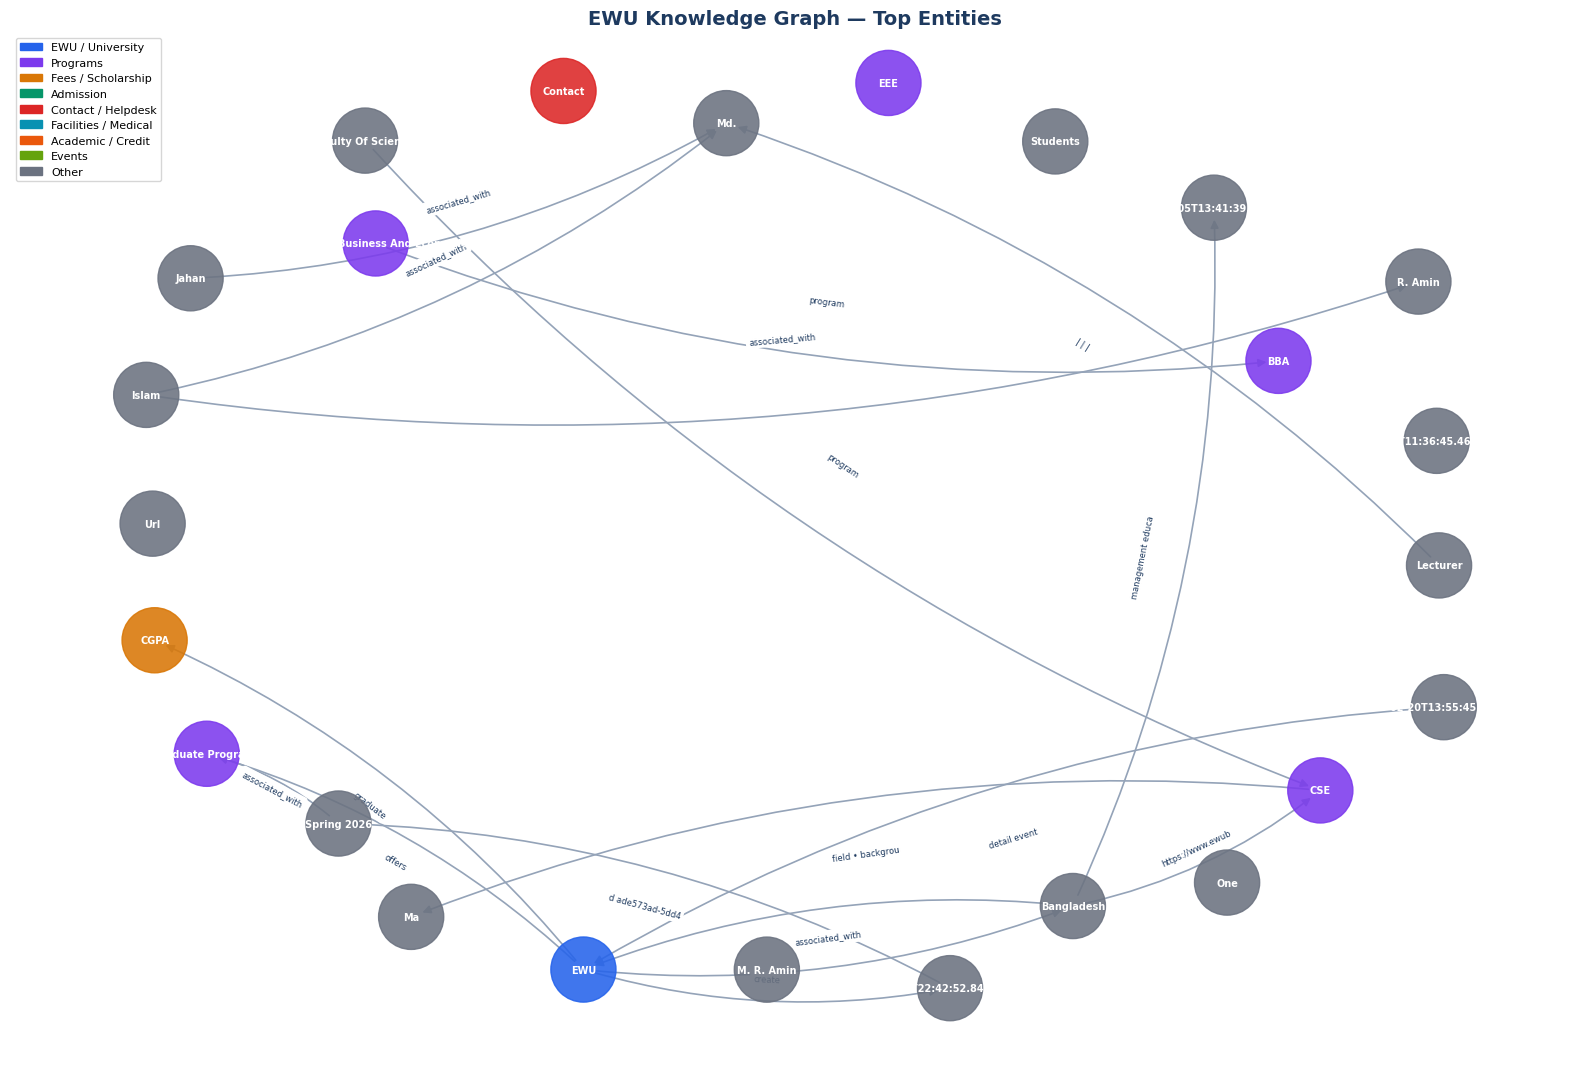

KG visualisation saved → /kaggle/working/results/kg_viz_20260409_1854.png


In [15]:
#  CELL 15 — KNOWLEDGE GRAPH VISUALISATION                 

def visualize_kg(KG: nx.DiGraph, top_n: int = 25):
    clean    = [(n, d) for n, d in KG.degree
                if not BAD_NODES.match(str(n).strip()) and not str(n).startswith("#")]
    hub_nodes = [n for n, _ in sorted(clean, key=lambda x: x[1], reverse=True)[:top_n]]
    subG     = KG.subgraph(hub_nodes)

    plt.figure(figsize=(16, 11))
    pos = nx.spring_layout(subG, seed=42, k=2.8)

    node_colors = []
    for n in subG.nodes():
        nl = str(n).lower()
        if any(x in nl for x in ["ewu", "university"]):
            node_colors.append("#2563EB")
        elif any(x in nl for x in ["cse", "eee", "bba", "mba", "law", "pharmacy", "economics", "program", "ms ", "ll.m"]):
            node_colors.append("#7C3AED")
        elif any(x in nl for x in ["scholarship", "tuition", "fee", "cgpa", "gpa", "merit", "need based", "freedom fighter"]):
            node_colors.append("#D97706")
        elif any(x in nl for x in ["admission", "ssc", "hsc", "requirement", "diploma", "undergraduate admission"]):
            node_colors.append("#059669")
        elif any(x in nl for x in ["contact", "helpdesk", "registrar", "email", "phone", "hotline"]):
            node_colors.append("#DC2626")
        elif any(x in nl for x in ["facilit", "medical", "library", "cafeteria","transport", "dormitory", "sports"]):
            node_colors.append("#0891B29")
        elif any(x in nl for x in ["credit", "cgpa", "gpa", "academic", "transfer"]):
            node_colors.append("#EA580C")
        elif any(x in nl for x in ["event"]):
            node_colors.append("#65A30D")
        else:
            node_colors.append("#6B7280")

    nx.draw_networkx_nodes(subG, pos, node_size=2200, node_color=node_colors, alpha=0.88)
    nx.draw_networkx_labels(subG, pos, font_size=7, font_color="white", font_weight="bold")
    nx.draw_networkx_edges(subG, pos, arrows=True, arrowsize=12,
                           edge_color="#94A3B8", width=1.2,
                           connectionstyle="arc3,rad=0.12")
    edge_labels = {(u, v): data["relations"][0][:16]
                   for u, v, data in subG.edges(data=True)
                   if data.get("relations")}
    nx.draw_networkx_edge_labels(subG, pos, edge_labels, font_size=6, font_color="#1E3A5F")

    from matplotlib.patches import Patch
    legend = [
        Patch(color="#2563EB", label="EWU / University"),
        Patch(color="#7C3AED", label="Programs"),
        Patch(color="#D97706", label="Fees / Scholarship"),
        Patch(color="#059669", label="Admission"),
        Patch(color="#DC2626", label="Contact / Helpdesk"),
        Patch(color="#0891B2", label="Facilities / Medical"),
        Patch(color="#EA580C", label="Academic / Credit"),
        Patch(color="#65A30D", label="Events"),
        Patch(color="#6B7280", label="Other"),
    ]
    plt.legend(handles=legend, loc="upper left", fontsize=8)
    plt.title("EWU Knowledge Graph — Top Entities",
              fontsize=14, fontweight="bold", color="#1E3A5F")
    plt.axis("off")
    plt.tight_layout()
    save_path = f"{RESULTS_DIR}/kg_viz_{datetime.now().strftime('%Y%m%d_%H%M')}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"KG visualisation saved → {save_path}")


visualize_kg(KG)